In [87]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers

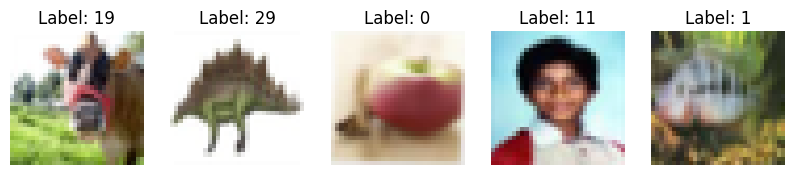

In [88]:
(train_x, train_y), (test_x, test_y) = tf.keras.datasets.cifar100.load_data()

num_classes = 100

plt.figure(figsize = (10, 2))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(train_x[i])
    plt.title(f"Label: {train_y[i][0]}")
    plt.axis('off')
plt.show()

In [89]:
print(train_x.min(), train_x.max())
train_x = train_x / 255.
test_x = test_x / 255.
print(train_x.min(), train_x.max())

0 255
0.0 1.0


In [90]:
input_shape = (32, 32, 3)
batch_size = 64

image_size = 72
patch_size = 6
num_patches = (image_size // patch_size) ** 2

learning_rate = 1e-3
weight_decay = 1e-4
epochs = 30

transformer_layers = 4
projection_dim = 64
num_heads = 4
transformer_units = [projection_dim * 2, projection_dim]
mlp_head_units = [2048, 1024]

In [91]:
class PatchTokenization(layers.Layer):
    def __init__(self, image_size=image_size, patch_size=patch_size, num_patches=num_patches, projection_dim=projection_dim,**kwargs):
        super().__init__(**kwargs)
        self.image_size=image_size
        self.patch_size=patch_size
        self.half_patch=patch_size/2
        self.flatten_patches=layers.Reshape((num_patches,-1))
        self.projection=layers.Dense(units=projection_dim)
        self.pater_norm=layers.LayerNormalization(epsilon=1e-6)

    def call(self,images):
        patches=tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1,self.patch_size,self.patch_size,1],
            rates=[1,1,1,1],
            padding='VALID'
        )
        flat_patches=self.flatten_patches(patches)
        tokens=self.projection(flat_patches)
        return (tokens, patches)

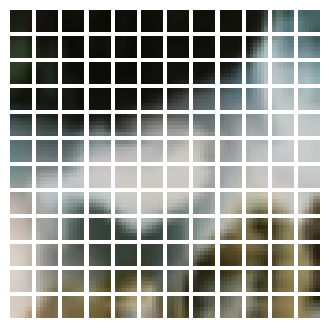

In [92]:
image = train_x[np.random.choice(range(train_x.shape[0]))]
resized_image = tf.image.resize(tf.convert_to_tensor([image]), size = (image_size, image_size))
(token, patch) = PatchTokenization()(resized_image)
(token, patch) = (token[0], patch[0])
n = patch.shape[0]
count = 1
plt.figure(figsize = (4, 4))
for row in range(n):
    for col in range(n):
        plt.subplot(n, n, count)
        count = count + 1
        image = tf.reshape(patch[row][col], (patch_size, patch_size, 3))
        plt.imshow(image)
        plt.axis('off')
plt.show()


In [93]:
class PatchEncoder(layers.Layer):
    def __init__(self, num_patches = num_patches, projection_dim = projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.position_embedding = layers.Embedding(input_dim = num_patches,
                                                   output_dim = projection_dim)
        self.positions = tf.range(start = 0, limit = self.num_patches, delta = 1)

    def call(self, encoded_patches):
        encoded_positions = self.position_embedding(self.positions)
        encoded_patches = encoded_patches + encoded_positions

        return encoded_patches

In [94]:
def mlp(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = layers.Dense(units, activation = tf.nn.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)

    return x

In [95]:
def create_vit_classifier():
    inputs = layers.Input(shape = input_shape)
    x = layers.Normalization()(inputs)
    x = layers.Resizing(image_size, image_size)(x)
    (tokens, _) = PatchTokenization()(x)
    encoded_patches = PatchEncoder()(tokens)

    for _ in range(transformer_layers):
        x1 = layers.LayerNormalization(epsilon = 1e-6)(encoded_patches)
        attention_output = layers.MultiHeadAttention(num_heads = num_heads,
                                                     key_dim = projection_dim, dropout = 0.1)(x1, x1)
        x2 = layers.Add()([attention_output, encoded_patches])
        x3 = layers.LayerNormalization(epsilon = 1e-6)(x2)
        x3 = mlp(x3, hidden_units = transformer_units, dropout_rate = 0.1)
        encoded_patches = layers.Add()([x3, x2])

        x = layers.LayerNormalization(epsilon= 1e-6)(encoded_patches)
        x = layers.Flatten()(x)
        x = layers.Dropout(0.5)(x)
        x = mlp(x, hidden_units = mlp_head_units, dropout_rate = 0.5)

        output = layers.Dense(num_classes)(x)
        model = tf.keras.Model(inputs = inputs, outputs = output)

    return model

In [96]:
class CosineDecay(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, learning_rate_base, total_steps, warmup_learning_rate, warmup_steps):
        super().__init__()
        self.learning_rate_base = learning_rate_base
        self.total_steps = total_steps
        self.warmup_learning_rate = learning_rate_base
        self.warmup_steps = warmup_steps
        self.pi = tf.constant(np.pi)

    def __call__(self, step):

        if self.total_steps < self.warmup_steps:
            raise ValueError("토털 스텝의 값이 웜업 스텝의 값보다 크거나 같아야 합니다.")

        cos_annealed_lr = tf.cos(self.pi * (tf.cast(step, tf.float32) - self.warmup_steps) / float(self.total_steps - self.warmup_steps))
        learning_rate = 0.5 * self.learning_rate_base * (1 - cos_annealed_lr)

        if self.warmup_steps > 0:
            if self.learning_rate_base < self.warmup_learning_rate:
                raise ValueError("학습률이 웜업 학습률보다 크거나 같아야 합니다.")

            slope = (self.learning_rate_base - self.warmup_learning_rate) / self.warmup_steps
            warmup_rate = slope * tf.cast(step, tf.float32) + self.warmup_learning_rate
            learning_rate = tf.where(step < self.warmup_steps, warmup_rate, learning_rate)

        return tf.where(step > self.total_steps, 0.0, learning_rate, name = "learning_rate")


In [97]:
total_steps = int((len(train_x) / batch_size) * epochs)
warmup_epoch_percentage = 0.10
warmup_steps = int(total_steps * warmup_epoch_percentage)
schedule_lrs = CosineDecay(
    learning_rate_base = learning_rate,
    total_steps = total_steps,
    warmup_learning_rate = 0.0,
    warmup_steps = warmup_steps,
)

In [98]:
# 비전 트랜스포머 선언

vit = create_vit_classifier()

optimizer = tf.keras.optimizers.Adam(
    learning_rate = schedule_lrs,
    weight_decay = weight_decay
)

vit.compile(
    optimizer = optimizer,
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits = True),
    metrics = [tf.keras.metrics.SparseCategoricalAccuracy(name = "accuracy"),
               tf.keras.metrics.SparseTopKCategoricalAccuracy(5, name = "top-5-accuracy")]
)

In [99]:
history = vit.fit(
    x = train_x,
    y = train_y,
    batch_size = batch_size,
    epochs = epochs,
    validation_split = 0.2
)

Epoch 1/30

625/625 [==============================] - 285s 440ms/step - loss: 4.6873 - accuracy: 0.0084 - top-5-accuracy: 0.0481 - val_loss: 4.6073 - val_accuracy: 0.0126 - val_top-5-accuracy: 0.0436
Epoch 2/30
625/625 [==============================] - 286s 458ms/step - loss: 4.6069 - accuracy: 0.0095 - top-5-accuracy: 0.0479 - val_loss: 4.6073 - val_accuracy: 0.0090 - val_top-5-accuracy: 0.0428
Epoch 3/30
625/625 [==============================] - 276s 441ms/step - loss: 4.6068 - accuracy: 0.0097 - top-5-accuracy: 0.0498 - val_loss: 4.6082 - val_accuracy: 0.0097 - val_top-5-accuracy: 0.0473
Epoch 4/30
625/625 [==============================] - 280s 448ms/step - loss: 4.6070 - accuracy: 0.0097 - top-5-accuracy: 0.0491 - val_loss: 4.6079 - val_accuracy: 0.0086 - val_top-5-accuracy: 0.0439
Epoch 5/30
625/625 [==============================] - 275s 440ms/step - loss: 4.6054 - accuracy: 0.0101 - top-5-accuracy: 0.0516 - val_loss: 4.6079 - val_accuracy: 0.0086 - val_top-5-accuracy: 0.0439

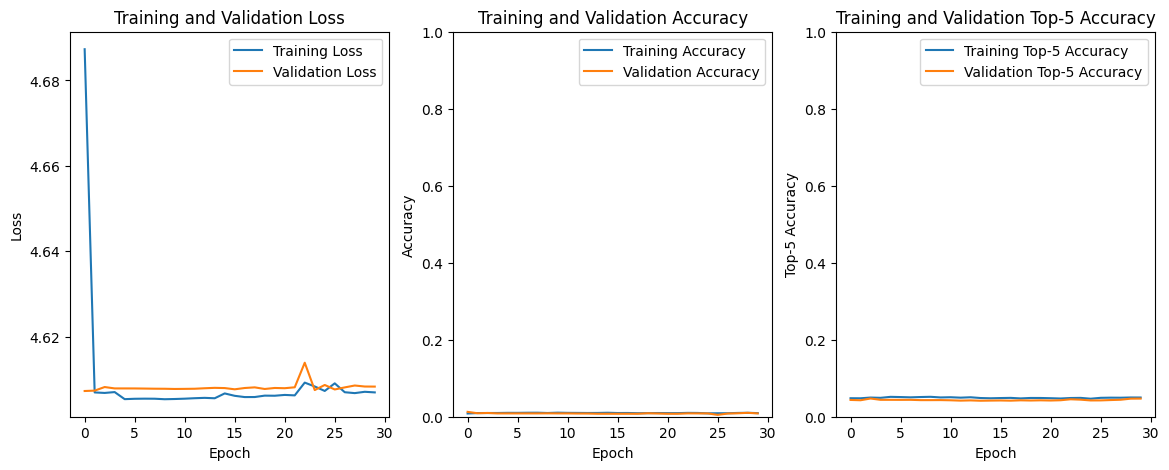

In [100]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history.history['top-5-accuracy'], label='Training Top-5 Accuracy')
plt.plot(history.history['val_top-5-accuracy'], label='Validation Top-5 Accuracy')
plt.title('Training and Validation Top-5 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Top-5 Accuracy')
plt.ylim(0, 1)
plt.legend()
plt.show()